In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

**Data Understanding**

In [ ]:
df = pd.read_csv("Copy of Telco_customer_churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.shape

(7043, 33)

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


**Data Cleaning & Preprocessing**

**a) Missing Values**

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


**Remove Duplicates**

In [ ]:
df.drop_duplicates(inplace=True)

**Handle Outliers**

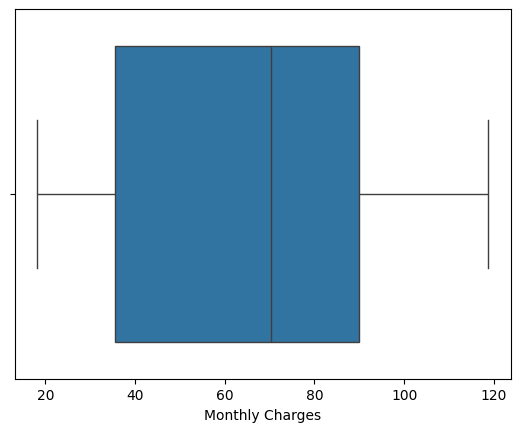

In [ ]:
sns.boxplot(x=df['Monthly Charges'])
plt.show()

**b) Encode Categorical Variables**

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**c) Feature Scaling**

In [ ]:
scaler = StandardScaler()

X = df.drop('Churn Value', axis=1)
X = scaler.fit_transform(X)

**Exploratory Data Analysis (EDA)**

**Churn Count**

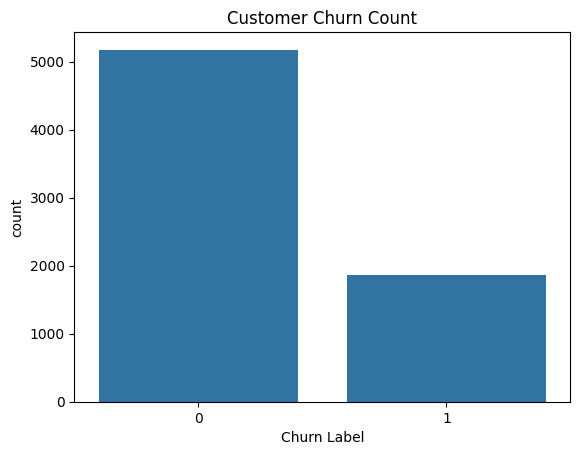

In [ ]:
sns.countplot(x='Churn Label', data=df)
plt.title("Customer Churn Count")
plt.show()

**Gender vs Churn**

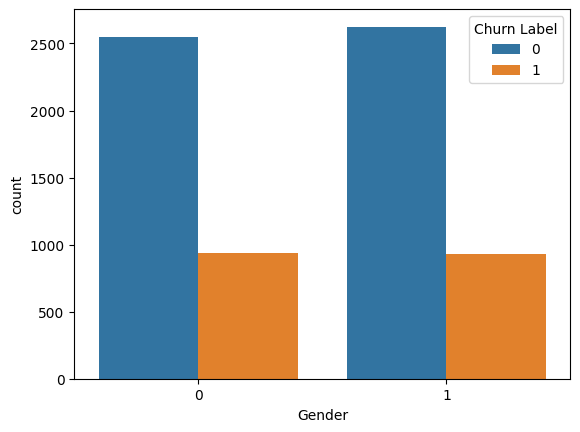

In [ ]:
sns.countplot(x='Gender', hue='Churn Label', data=df)
plt.show()

**Monthly Charges Distribution**

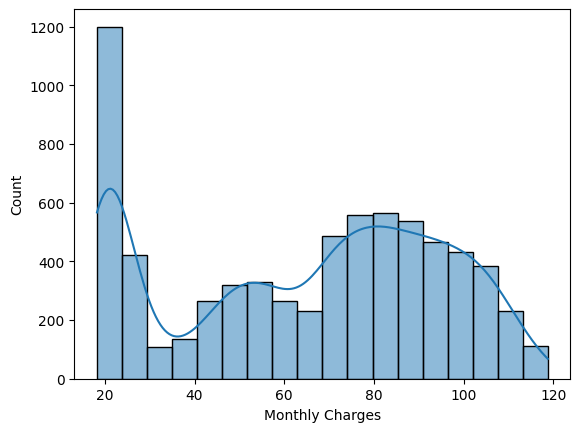

In [ ]:
sns.histplot(df['Monthly Charges'], kde=True)
plt.show()

**Correlation Heatmap**

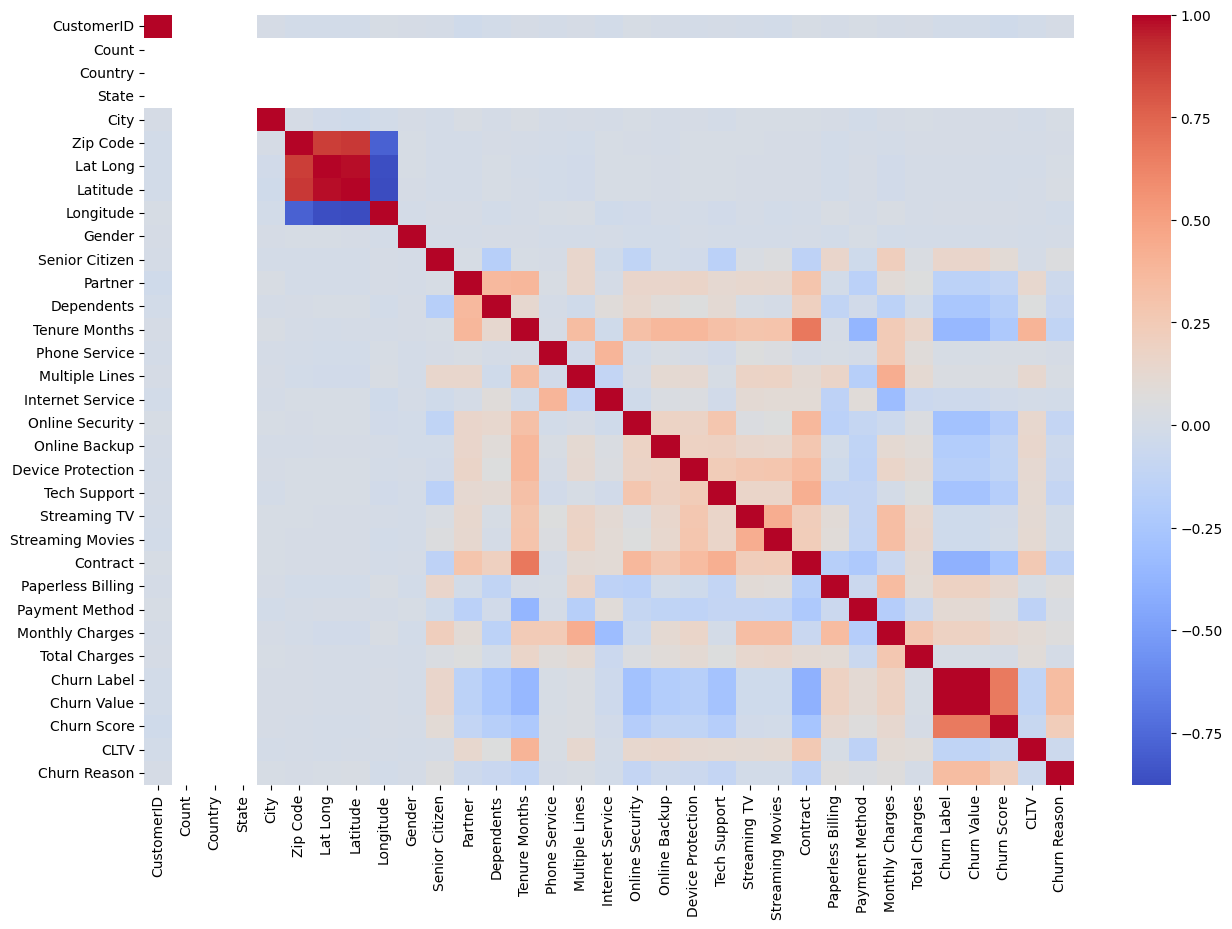

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

**Model Building**

**Target Variable**

In [ ]:
# Target variable
y = df['Churn Value']

# Drop unwanted columns
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Value',
    'Churn Score',
    'Churn Reason'
]

X = df.drop(columns=drop_cols)

print(X.columns)
print(X.shape)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV'],
      dtype='object')
(7043, 20)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model 1: Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)

pred1 = lr.predict(X_test_scaled)

print("Logistic Regression:", accuracy_score(y_test, pred1))

Logistic Regression: 0.8041163946061036


**Build Model 2 (Decision Tree)**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred2 = dt.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, pred2))

Decision Tree: 0.7423704755145494


**Build Model 3 (Random Forest)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred3 = rf.predict(X_test)

print("Random Forest:", accuracy_score(y_test, pred3))

Random Forest: 0.7906316536550745


**Compare All Models**

In [ ]:
print("Logistic Regression :", accuracy_score(y_test, pred1))
print("Decision Tree       :", accuracy_score(y_test, pred2))
print("Random Forest       :", accuracy_score(y_test, pred3))

Logistic Regression : 0.8041163946061036
Decision Tree       : 0.7423704755145494
Random Forest       : 0.7906316536550745


**Classification Report (Best Model)**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1009
           1       0.69      0.56      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



**Confusion Matrix**

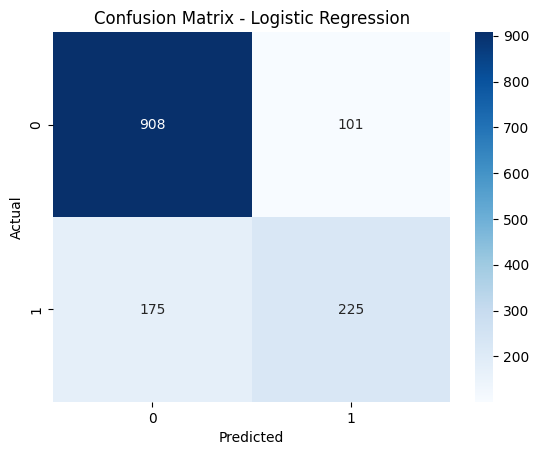

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred1)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve + AUC Score**

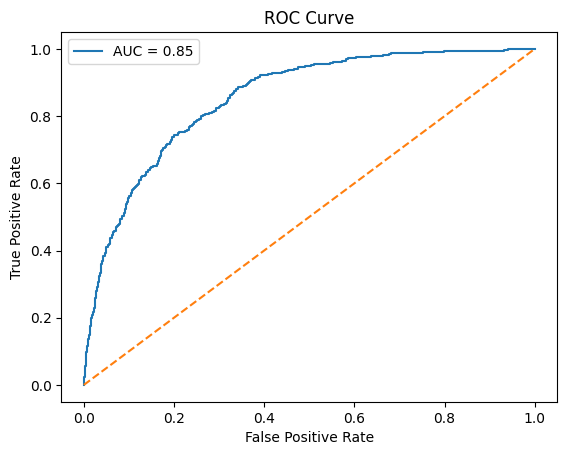

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = %.2f" % auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**Find Important Features**

In [ ]:
coeff = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coeff = coeff.sort_values(by='Coefficient', ascending=False)
print(coeff)

              Feature  Coefficient
17    Monthly Charges     0.782556
15  Paperless Billing     0.189898
7    Internet Service     0.147205
2             Partner     0.136107
18      Total Charges     0.115309
6      Multiple Lines     0.110822
16     Payment Method     0.069243
1      Senior Citizen     0.047905
19               CLTV     0.025809
12       Streaming TV     0.015256
13   Streaming Movies    -0.009764
0              Gender    -0.017798
10  Device Protection    -0.030444
9       Online Backup    -0.080312
11       Tech Support    -0.200578
8     Online Security    -0.217921
5       Phone Service    -0.252921
14           Contract    -0.599380
3          Dependents    -0.618807
4       Tenure Months    -0.939361


**Final Accuracy Comparison Chart**

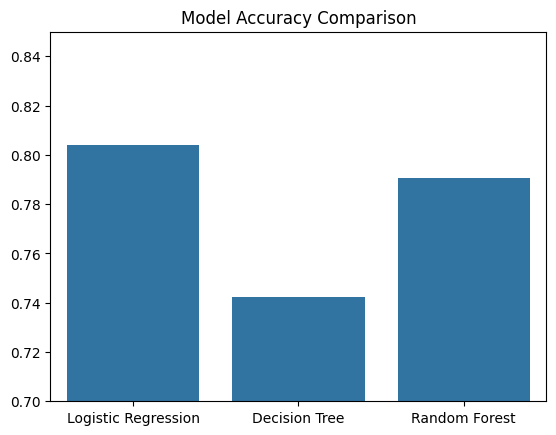

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
scores = [0.8041, 0.7423, 0.7906]

sns.barplot(x=models, y=scores)
plt.title("Model Accuracy Comparison")
plt.ylim(0.70,0.85)
plt.show()

**Visualize Top Features**

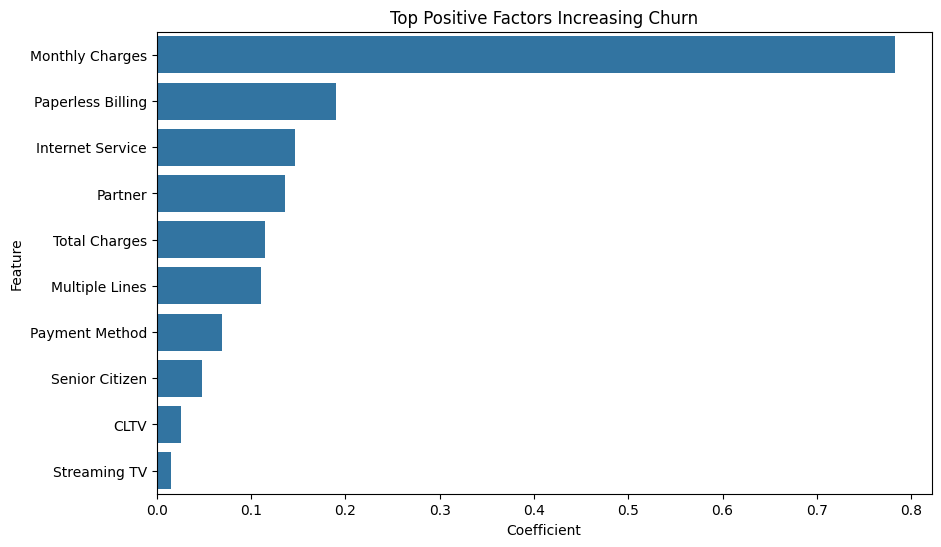

In [ ]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=top10)
plt.title("Top Positive Factors Increasing Churn")
plt.show()

**Visualize Features Reducing Churn**

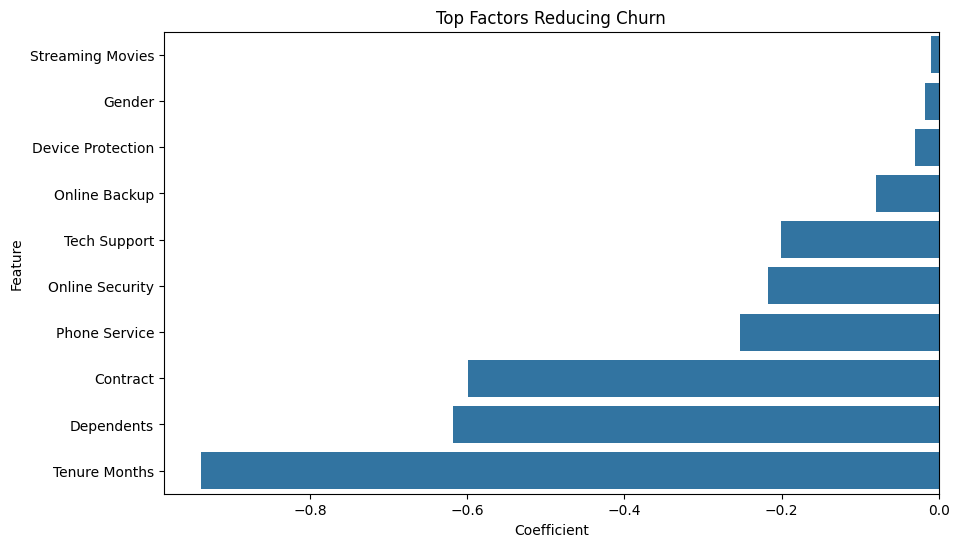

In [ ]:
bottom10 = importance.tail(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=bottom10)
plt.title("Top Factors Reducing Churn")
plt.show()

**Customer Churn Percentage**

In [ ]:
churn_rate = df['Churn Value'].mean()*100
print("Overall Churn Rate: %.2f%%" % churn_rate)

Overall Churn Rate: 26.54%


**Contract Type vs Churn**

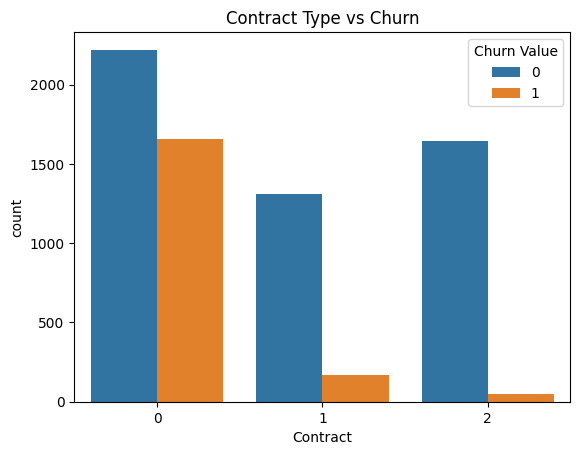

In [ ]:
sns.countplot(x='Contract', hue='Churn Value', data=df)
plt.title("Contract Type vs Churn")
plt.show()

**Monthly Charges vs Churn**

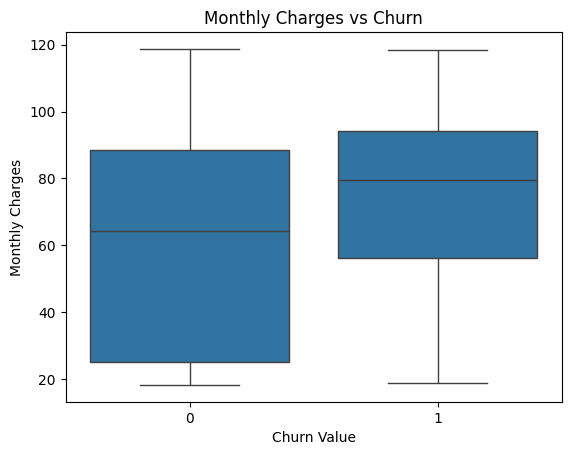

In [ ]:
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Tenure vs Churn**

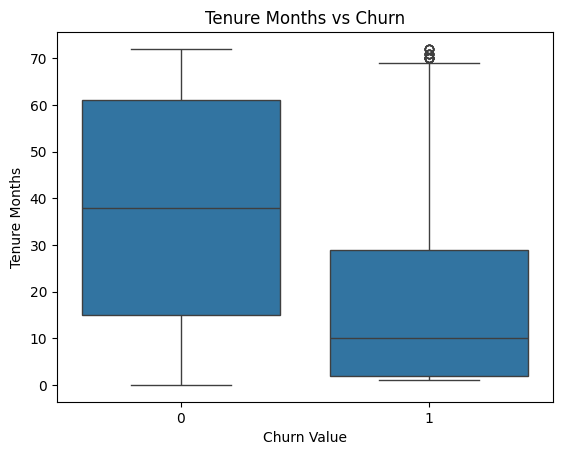

In [ ]:
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)
plt.title("Tenure Months vs Churn")
plt.show()

**Save Final Dataset**

In [ ]:
df.to_csv("Final_Cleaned_Telco_Churn.csv", index=False)